# 6. Diversity Analysis (Alpha & Beta)
## Import data & packages

In [25]:
# 1 - Import packages
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy.stats import shapiro, kruskal, f_oneway
import numpy as np
  
%matplotlib inline

In [11]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/scripts").


In [31]:
# 3 - Data directories
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
daa_data_dir = "../data/processed/differential_abundance"
# Create the new differential abundance analysis folder

In [4]:
%%bash -s "$daa_data_dir"
mkdir -p "$1"

# 1. Data exploration: look at feature table

We want to have a look at the feature table to check if it is sparse (a lot of zero-values) and to have a look at the data distribution. We can see in the table that there are quite a lot of zero-values and from the violin-plot we can see that the data is not normally distributed. We additionally did the Shapiro-Wilk test to check if the data is normally distributed, since we only plotted 15 samples. Further down in the results we can see that the data indeed is not normally distributed.

In [7]:
#import and plot feature table to check for zero-values
data = q2.Artifact.load(f'{denoised_data_dir}/dada2_table.qza').view(pd.DataFrame)

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [8]:
data.head()

,35ffcc3b809d667286737d79670b8de5,d46e2205f0c6ecf67b51f83d111c509c,2c982937754e6321f861027032db80f7,99deb3c5ecb022ec05609ebd1112a557,fd44d4cb468fd7dc9b3227867714ed87,2c5e87b291147c04e1b8d1c808b1aee0,c24e0e391aa836b5eae25567c7eb89ee,9908fffab7ed4f3bec44cda2f5084d49,315ca0a729f126b941ba111a16d4d97a,945184b6386c192c0066e0a98a154780,...,2bce8615134b73991ef0e14272646791,3a5317c713023cb528a3d6ea8edaf0a3,0a764c782ff16c18e0e2bde8d46d4608,74cd5ddaf80f3aabb34845c1558d1e54,98d918d67a235038cddd3e27015d9f39,f995b00628c62422bfba901c52048e10,ef500a1b2cafbc7ea19d914cc368cba0,6871fd2ae0f5548e5b16e9cdd0f767ac,919f2dcd2712ba221a695b4a98c5651c,efaa636ca54aed7c824dd9f521028c6b
SRR8115637,12850.0,12487.0,0.0,0.0,0.0,0.0,190.0,1903.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115646,2488.0,500.0,72.0,5071.0,0.0,901.0,1071.0,0.0,9365.0,381.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115666,387.0,1145.0,0.0,9942.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115682,5982.0,333.0,0.0,0.0,0.0,37.0,204.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115685,7066.0,0.0,0.0,0.0,0.0,0.0,221.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
#violin plot to check if data is normally distributed
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

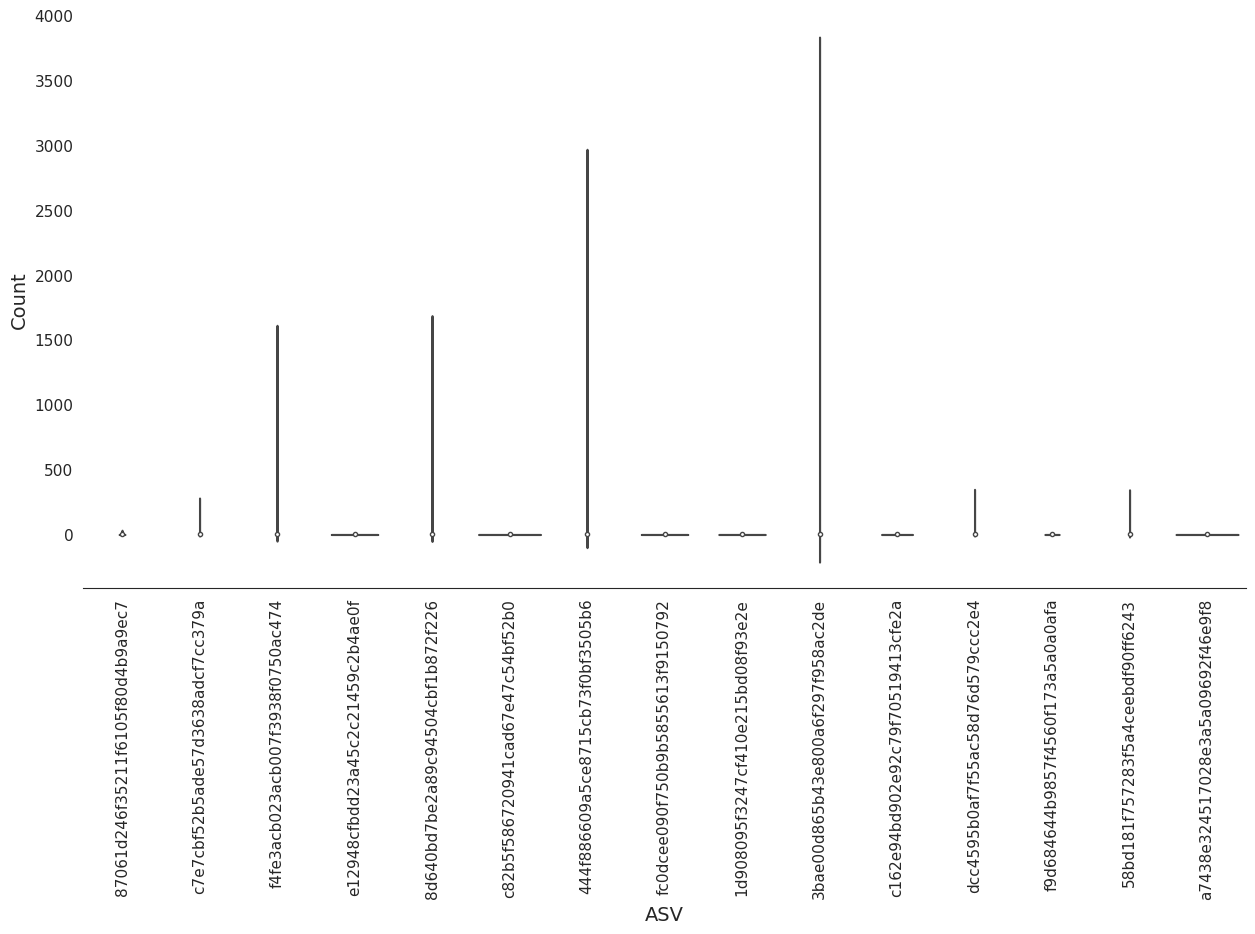

In [10]:
with sns.axes_style('white'), sns.color_palette('Set1'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

In [11]:
#statistically testing for normality 
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [12]:
results_df

,p,is_normal
35ffcc3b809d667286737d79670b8de5,5.141034e-33,False
d46e2205f0c6ecf67b51f83d111c509c,1.878576e-32,False
2c982937754e6321f861027032db80f7,3.512602e-33,False
99deb3c5ecb022ec05609ebd1112a557,3.600188e-32,False
fd44d4cb468fd7dc9b3227867714ed87,4.138422e-34,False
...,...,...
f995b00628c62422bfba901c52048e10,7.024117e-39,False
ef500a1b2cafbc7ea19d914cc368cba0,7.024117e-39,False
6871fd2ae0f5548e5b16e9cdd0f767ac,7.024117e-39,False
919f2dcd2712ba221a695b4a98c5651c,7.024117e-39,False


In [13]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


# 2. ANCOM-BC
For the differential analysis we will use different methods and create a consensus set of differnetially abundant features in the end. The first method that we use is ANCOM-BC, Analysis of Compositions of Microbiomes with Bias Correction, which estimates the unknown sampling fractions and corrects the bias induced by their differences among samples. ANCOM uses relative abundances to infer about absolute abundances. One of the deficiencies of ANCOM is that it does not provide p value for individual taxon, nor can it provide standard errors or confidence intervals of DA for each taxon, and it can be computationally intensive [Lin, H., Peddada, S.D. Analysis of compositions of microbiomes with bias correction. Nat Commun 11, 3514 (2020). https://doi.org/10.1038/s41467-020-17041-7]. We performed ANCOM-BC for delivery mode (vaginal or cesarean) and for the infant's diet (milk-doiminant or formula-dominant).

## 2.1 Delivery Mode

In [32]:
# create folder for delivery mode
!mkdir -p "$daa_data_dir/delivery_mode"

In [33]:
! qiime feature-table filter-features \
    --i-table $denoised_data_dir/dada2_table.qza \
    --p-min-frequency 25 \
    --p-min-samples 4 \
    --o-filtered-table $daa_data_dir/table_abund.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/table_abund.qza


In [34]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-where "[delivery_mode]='vaginal' or [delivery_mode]='cesarean'" \
    --o-filtered-table $daa_data_dir/delivery_mode/table_abund_deliverymode.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/delivery_mode/table_abund_deliverymode.qza


In [35]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/delivery_mode/table_abund_deliverymode.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-formula delivery_mode \
    --o-differentials $daa_data_dir/delivery_mode/ancombc_deliverymode_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/delivery_mode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/delivery_mode/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/delivery_mode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/delivery_mode/ancombc_deliverymode_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/delivery_mode/ancombc_deliverymode_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/delivery_mode/ancombc_deliverymode_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources 

In [ ]:
Visualization.load(f"{daa_data_dir}/delivery_mode/ancombc_deliverymode_da_barplot.qzv")

In [ ]:
Visualization.load(f"{daa_data_dir}/delivery_mode/ancombc_deliverymode_results.qzv")

## 2.2 Diet Milk

In [5]:
# create folder for diet
!mkdir -p "$daa_data_dir/diet"

In [10]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-where "[diet_milk]='bd' or [diet_milk]='fd'" \
    --o-filtered-table $daa_data_dir/diet/table_abund_diet.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/diet/table_abund_diet.qza


In [ ]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/diet/table_abund_diet.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-formula diet_milk \
    --o-differentials $daa_data_dir/diet/ancombc_diet_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/diet/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/diet/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/diet/ancombc_deliverymode_results.qzv

In [ ]:
Visualization.load(f"{daa_data_dir}/diet/ancombc_diet_da_barplot.qzv")

In [ ]:
Visualization.load(f"{daa_data_dir}/diet/ancombc_diet_results.qzv")

## Diet Milk including taxonomy

In [13]:
# add taxonomy
! qiime taxa collapse \
    --i-table $daa_data_dir/table_abund.qza \
    --i-taxonomy $taxonomy_data_dir/taxonomy.qza \
    --p-level 6 \
    --o-collapsed-table $daa_data_dir/table_abund_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/table_abund_l6.qza


In [28]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-where "[diet_milk]='bd' or [diet_milk]='fd'" \
    --o-filtered-table $daa_data_dir/diet/table_abund_bd_fd_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/diet/table_abund_bd_fd_l6.qza


In [32]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/diet/table_abund_bd_fd_l6.qza \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --p-formula diet_milk \
    --o-differentials $data_dir/diet/ancombc_diet_l6_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/diet/ancombc_diet_l6_differentials.qza \
    --o-visualization $daa_data_dir/diet/ancom_diet_l6.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/diet/ancombc_diet_l6_differentials.qza \
    --o-visualization $daa_data_dir/diet/ancombc_diet_l6_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
There was an issue with loading the file /metadata.tsv as metadata:

  Metadata file path doesn't exist, or the path points to something other than a file. Please check that the path exists, has read permissions, and points to a regular file (not a directory): /metadata.tsv

  There may be more errors present in the metadata file. To get a full report, sample/feature metadata files can be validated with Keemei: https://keemei.qiime2.org

  Find details on QIIME 2 metadata requirements here: https://docs.qiime2.org/2025.7/tutorials/metadata/

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https

In [30]:
Visualization.load(f"{daa_data_dir}/diet/ancom_diet_l6.qzv")

ValueError: ../data/processed/differential_abundance/diet/ancom_diet_l6.qzv does not exist.

In [ ]:
Visualization.load(f"{daa_data_dir}/diet/ancombc_env_l6_results.qzv")

In [ ]:
! qiime feature-table summarize \
    --i-table $daa_data_dir/diet/table_abund_bd_fd_l6.qza \
    --m-sample-metadata-file $raw_data_dir/metadata.tsv \
    --o-visualization $daa_data_dir/diet/abund_diet_l6_summary.qzv

In [ ]:
Visualization.load(f"{data_dir}/diet/abund_diet_l6_summary.qzv")

## Volcano Plot

In [ ]:
!qiime tools export \
  --input-path $daa_data_dir/diet/ancombc_diet_l6_differentials.qza \
  --output-path $daa_data_dir/diet/ancombc_diet_l6_differentials_export

In [ ]:
# Path to exported TSV
tsv_file = "$daa_data_dir/diet/ancombc_diet_l6_differentials_export/differentials.tsv"

# Load
df_diet_volcano = pd.read_csv(tsv_file, sep="\t")
df_diet_volcano.head()

In [ ]:
# Add -log10(p_adj)
df_diet_volcano['neg_log10_q'] = -np.log10(df_diet_volcano['p_adj'])

# Mark significant features (q < 0.05)
df_diet_volcano['significant'] = df_diet_volcano['p_adj'] < 0.05

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_diet_volcano,
    x='diet_milk',           # effect size / log fold change
    y='neg_log10_q',
    hue='significant',
    palette={True: 'red', False: 'grey'},
    edgecolor=None
)

plt.axhline(-np.log10(0.05), color='blue', linestyle='--', lw=1)
plt.xlabel("Log fold change (diet_milk)")
plt.ylabel("-log10(q-value)")
plt.title("Volcano Plot - ANCOM-BC Differential Abundance")
plt.legend(title='Significant (q<0.05)')
plt.show()


# 4. MaAsLin2
https://github.com/biobakery/Maaslin2

MaAsLin2 finds associations between microbiome multi-omics features and complex metadata in population-scale epidemiological studies. The software includes multiple analysis methods (including support for multiple covariates and repeated measures), filtering, normalization, and transform options.

1. Install packages in terminal (R)
2. Export feature table including taxonomy (l6) to use as data input
3. Use exported metadata
4. Run MaAsLin2: use LM model, TSS normalization, try transorm = LOG, add random_effects = host_id, fixed_effects = age?

In [15]:
! qiime tools export \
    --input-path $daa_data_dir/table_abund_l6.qza \
    --output-path $daa_data_dir/table_abund_l6_export

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/table_abund_l6.qza as BIOMV210DirFmt to directory ../data/processed/differential_abundance/table_abund_l6_export


In [17]:
! biom convert \
    -i $daa_data_dir/table_abund_l6_export/feature-table.biom \
    -o $daa_data_dir/table_abund_l6_export/feature-table.tsv \
    --to-tsv

In [16]:
%load_ext rpy2.ipython

In [22]:
%%R
library(Maaslin2)

fit <- Maaslin2(
    input_data = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/denoising/exported-feature-table/feature-table.tsv",
    input_metadata = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/raw/metadata.tsv",
    output = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output",
    normalization = "TSS",
    transform = "LOG",
    analysis_method = "LM",
    fixed_effects = c("age_months", "treatment_exposure", "delivery_mode"),
    random_effects = c("host_id")
)

[1] "Warning: Deleting existing log file: /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output/maaslin2.log"
2025-11-26 12:45:01.217129 INFO::Writing function arguments to log file
2025-11-26 12:45:01.249724 INFO::Verifying options selected are valid
2025-11-26 12:45:01.253415 INFO::Determining format of input files
2025-11-26 12:45:01.257262 INFO::Input format is data samples as columns and metadata samples as rows
2025-11-26 12:45:01.401126 INFO::Formula for random effects: expr ~ (1 | host_id)
2025-11-26 12:45:01.405165 INFO::Formula for fixed effects: expr ~  age_months + treatment_exposure + delivery_mode
2025-11-26 12:45:01.409406 INFO::Filter data based on min abundance and min prevalence
2025-11-26 12:45:01.412673 INFO::Total samples in data: 357
2025-11-26 12:45:01.416001 INFO::Min samples required with min abundance for a feature not to be filtered: 35.700000
2025-11-26 12:45:01.500923 INFO::Total filtered features: 3769
202

R[write to console]: boundary (singular) fit: see help('isSingular')



2025-11-26 12:45:06.232743 INFO::Fitting model to feature number 62, X5f8d35126b0a7321413d21487ec72b73
  |++++++++++++++++++++++++++++++                    | 60% ~03s          2025-11-26 12:45:06.30232 INFO::Fitting model to feature number 63, X56bde454092279f47b556883d5909620
2025-11-26 12:45:06.367959 INFO::Fitting model to feature number 64, X3916a456bb0a3bfd02c15fd537ff5923
  |+++++++++++++++++++++++++++++++                   | 62% ~03s          2025-11-26 12:45:06.442486 INFO::Fitting model to feature number 65, d380b9ae91e3875a70ff329e4889cb72
2025-11-26 12:45:06.502774 INFO::Fitting model to feature number 66, X3bae00d865b43e800a6f297f958ac2de
  |++++++++++++++++++++++++++++++++                  | 63% ~03s          2025-11-26 12:45:06.571116 INFO::Fitting model to feature number 67, eae880eaa9c99650e399d9b4eb5dd3b0
2025-11-26 12:45:06.636351 INFO::Fitting model to feature number 68, X59777186ad2e0947e97615b5d6225136
  |+++++++++++++++++++++++++++++++++                 | 65% ~03s

R[write to console]: boundary (singular) fit: see help('isSingular')



  |+++++++++++++++++++++++++++++++++++               | 69% ~02s          2025-11-26 12:45:06.962613 INFO::Fitting model to feature number 73, X06f825b512d903b9230e1a55d87359ee
2025-11-26 12:45:07.037973 INFO::Fitting model to feature number 74, X818434292143daca42a3168f3728da82
  |++++++++++++++++++++++++++++++++++++              | 71% ~02s          2025-11-26 12:45:07.102814 INFO::Fitting model to feature number 75, X05dbbf0301a9625e1f1a41470a92f7fe
2025-11-26 12:45:07.167976 INFO::Fitting model to feature number 76, X2c6a6015a325f35c1a5c8ce7a44a5e3c
  |+++++++++++++++++++++++++++++++++++++             | 73% ~02s          2025-11-26 12:45:07.237711 INFO::Fitting model to feature number 77, X7af6fc12809fdafab918881f836460f8
2025-11-26 12:45:07.301276 INFO::Fitting model to feature number 78, bed671b4676144142cebd192b690f499
  |++++++++++++++++++++++++++++++++++++++            | 75% ~02s          2025-11-26 12:45:07.386323 INFO::Fitting model to feature number 79, dd918c333e5c4fef9c9206

...

  |++++++++++++++++++++++++++++++++++++++++++++      | 87% ~01s          2025-11-26 12:45:08.193773 INFO::Fitting model to feature number 91, X4f5efd25dacb5d639316e7291ff6ff8b
2025-11-26 12:45:08.262155 INFO::Fitting model to feature number 92, X6376ea6dab7d0fde3cd66f53b57e1484
  |+++++++++++++++++++++++++++++++++++++++++++++     | 88% ~01s          2025-11-26 12:45:08.344688 INFO::Fitting model to feature number 93, X2ce81730307fd61bb123d04c96e98b76
2025-11-26 12:45:08.41183 INFO::Fitting model to feature number 94, X149465e40c1bdbc6230588a58a4d6eb0
  |++++++++++++++++++++++++++++++++++++++++++++++    | 90% ~01s          2025-11-26 12:45:08.478076 INFO::Fitting model to feature number 95, X0a1dedddb1e5f66d71fd2909c7cc84e7
2025-11-26 12:45:08.541818 INFO::Fitting model to feature number 96, X85c44c83eddc5d3028261a1000b7d0e1
  |+++++++++++++++++++++++++++++++++++++++++++++++   | 92% ~01s          2025-11-26 12:45:08.610914 INFO::Fitting model to feature number 97, X5a2676b27aa16876cffac

R[write to console]: boundary (singular) fit: see help('isSingular')



  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=07s  
2025-11-26 12:45:09.189994 INFO::Counting total values for each feature
2025-11-26 12:45:09.208611 INFO::Writing filtered data to file /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output/features/filtered_data.tsv
2025-11-26 12:45:09.249687 INFO::Writing filtered, normalized data to file /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output/features/filtered_data_norm.tsv
2025-11-26 12:45:09.30006 INFO::Writing filtered, normalized, transformed data to file /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output/features/filtered_data_norm_transformed.tsv
2025-11-26 12:45:09.365555 WARNING::Deleting existing residuals file: /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output/fits/residuals.rds
2025-11-26 12:45:

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'

R[write to console]: `geom_smooth()` using formula = 'y ~ x'



2025-11-26 12:45:26.730767 INFO::Plotting data for metadata number 2, treatment_exposure
2025-11-26 12:45:26.738907 INFO::Creating boxplot for categorical data, treatment_exposure vs X2c5e87b291147c04e1b8d1c808b1aee0
2025-11-26 12:45:26.930969 INFO::Creating boxplot for categorical data, treatment_exposure vs fd496fd32dc8c08ade2e8b6c9d8ee13d
2025-11-26 12:45:27.157469 INFO::Creating boxplot for categorical data, treatment_exposure vs X6376ea6dab7d0fde3cd66f53b57e1484
2025-11-26 12:45:27.38269 INFO::Creating boxplot for categorical data, treatment_exposure vs X0a1dedddb1e5f66d71fd2909c7cc84e7
2025-11-26 12:45:27.564029 INFO::Creating boxplot for categorical data, treatment_exposure vs X9908fffab7ed4f3bec44cda2f5084d49
2025-11-26 12:45:27.773122 INFO::Creating boxplot for categorical data, treatment_exposure vs a443e786f67086749ef29ce0ab494c9e
2025-11-26 12:45:28.023381 INFO::Creating boxplot for categorical data, treatment_exposure vs a8a9a05f11ee2bad8fa87bdfb414b594
2025-11-26 12:45:28

In [23]:
results = pd.read_csv(
    f"{daa_data_dir}/maaslin2_output/all_results.tsv",
    sep="\t"
)

# Preview
results.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,c6c3ab4e828fb40d6e05967b7aac9338,age_months,age_months,2.156659,0.204774,357,141,5.904362e-22,1.842161e-19
1,a663a01aeb4dbb88bbe0a9840e8f64dc,age_months,age_months,1.619890,0.208893,357,164,1.980749e-13,3.089969e-11
2,X8e175abe6a746b8f33bae9cd7c8192bb,age_months,age_months,1.443790,0.190162,357,99,4.363142e-13,4.537668e-11
3,X5c4563e3dd7e12dcdf279783af929eaa,age_months,age_months,1.284793,0.172282,357,61,9.146619e-13,7.056314e-11
4,X5f8d35126b0a7321413d21487ec72b73,age_months,age_months,0.913576,0.121932,357,103,1.130820e-12,7.056314e-11


In [26]:
# Add -log10 q-value
results['neg_log10_q'] = -np.log10(results['qval'])

# Add a significance column
results['significant'] = results['qval'] < 0.05

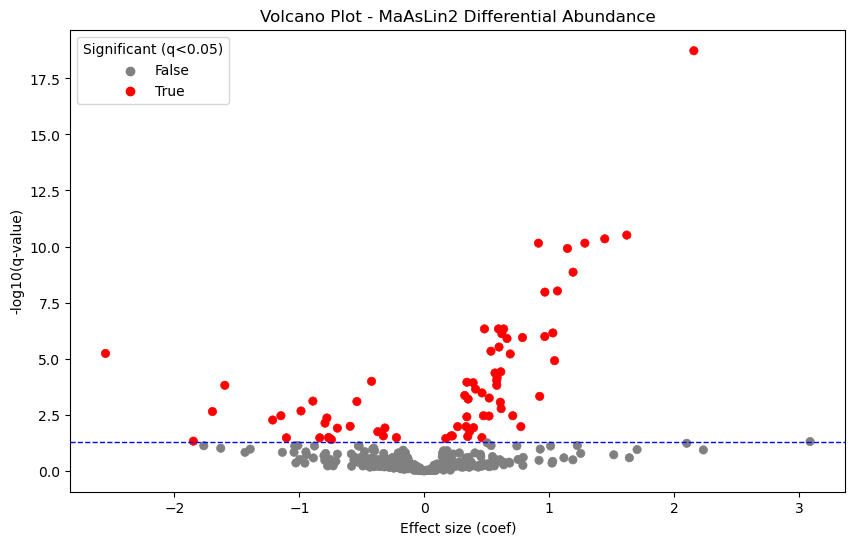

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

# Scatter plot
sns.scatterplot(
    data=results,
    x='coef',
    y='neg_log10_q',
    hue='significant',
    palette={True: 'red', False: 'grey'},
    edgecolor=None
)

# Add horizontal line at q=0.05
plt.axhline(-np.log10(0.05), color='blue', linestyle='--', lw=1)

plt.xlabel("Effect size (coef)")
plt.ylabel("-log10(q-value)")
plt.title("Volcano Plot - MaAsLin2 Differential Abundance")
plt.legend(title='Significant (q<0.05)')
plt.show()
